In [38]:
print("Hello, coral reefs!")

Hello, coral reefs!


In [39]:

import subprocess
subprocess.run(["pip", "install", "pygbif", "pandas", "matplotlib", "seaborn"])

CompletedProcess(args=['pip', 'install', 'pygbif', 'pandas', 'matplotlib', 'seaborn'], returncode=0)

In [40]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pygbif import occurrences as occ

print("Все библиотеки загружены ✓")

Все библиотеки загружены ✓


In [41]:
# Reload data with better filters for global diversity
results = occ.search(
    classKey=206,           # Anthozoa
    mediaType='StillImage', # only observations with photos
    hasCoordinate=True,     # only with coordinates
    limit=300,
    year='2015,2024',       # broader year range
    country=['AU', 'PH', 'ID', 'FJ', 'MX', 'JP', 'US', 'MV', 'ZA', 'BR']
)

df = pd.DataFrame(results['results'])

# Keep only the columns we need
cols = ['species', 'country', 'decimalLatitude', 'decimalLongitude', 'year', 'month', 'basisOfRecord']
cols_exist = [c for c in cols if c in df.columns]
df = df[cols_exist]

# Drop rows without species name
df = df.dropna(subset=['species'])

print(f"Total records: {len(df)}")
print("\nCountry distribution:")
print(df['country'].value_counts())
print(f"\nYear range: {df['year'].min()} to {df['year'].max()}")

Total records: 296

Country distribution:
country
United States of America    182
Australia                    73
Brazil                       20
Philippines                   7
Fiji                          5
Mexico                        4
Indonesia                     4
South Africa                  1
Name: count, dtype: int64

Year range: 2024 to 2024


In [49]:
import time

# Countries with rich coral reef data
countries = {
    'AU': 'Australia',
    'PH': 'Philippines', 
    'ID': 'Indonesia',
    'FJ': 'Fiji',
    'MV': 'Maldives',
    'JP': 'Japan',
    'MX': 'Mexico',
    'BR': 'Brazil',
    'US': 'United States'
}

all_results = []

for code, name in countries.items():
    results = occ.search(
        classKey=206,
        mediaType='StillImage',
        hasCoordinate=True,
        country=code,
        year='2015,2024',
        limit=50           # 50 per country = ~450 total
    )
    records = results['results']
    all_results.extend(records)
    print(f"✓ {name}: {len(records)} records")
    time.sleep(0.5)        # be polite to the API

# Combine into one DataFrame
df = pd.DataFrame(all_results)

cols = ['species', 'country', 'decimalLatitude', 'decimalLongitude', 'year', 'month', 'basisOfRecord']
cols_exist = [c for c in cols if c in df.columns]
df = df[cols_exist]
df = df.dropna(subset=['species'])

print(f"\nTotal records: {len(df)}")
print("\nCountry distribution:")
print(df['country'].value_counts())
print(f"\nYear range: {df['year'].min()} to {df['year'].max()}")

✓ Australia: 50 records
✓ Philippines: 50 records
✓ Indonesia: 50 records
✓ Fiji: 50 records
✓ Maldives: 50 records
✓ Japan: 50 records
✓ Mexico: 50 records
✓ Brazil: 50 records
✓ United States: 50 records

Total records: 447

Country distribution:
country
Australia                   50
Philippines                 50
Fiji                        50
Maldives                    50
Japan                       50
Mexico                      50
Brazil                      50
United States of America    50
Indonesia                   47
Name: count, dtype: int64

Year range: 2024 to 2024


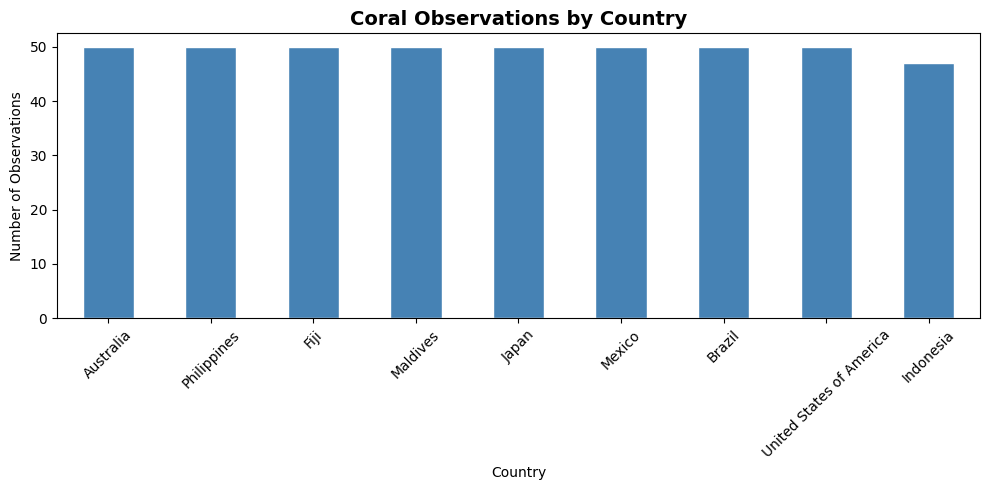

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))

df['country'].value_counts().plot(
    kind='bar',
    ax=ax,
    color='steelblue',
    edgecolor='white'
)

ax.set_title('Coral Observations by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Observations')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

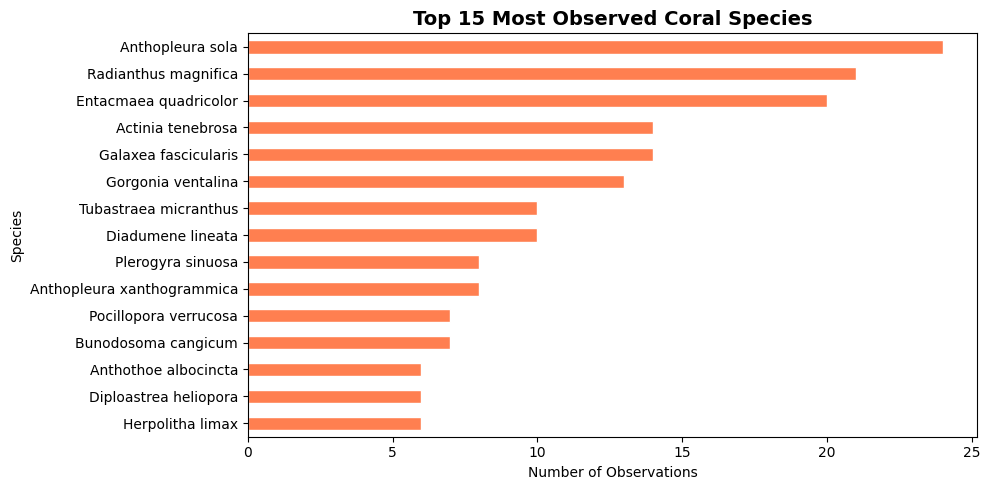

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

df['species'].value_counts().head(15).plot(
    kind='barh',      # horizontal bars — easier to read long species names
    ax=ax,
    color='coral',
    edgecolor='white'
)

ax.set_title('Top 15 Most Observed Coral Species', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Observations')
ax.set_ylabel('Species')
ax.invert_yaxis()    # most common species at the top

plt.tight_layout()
plt.show()

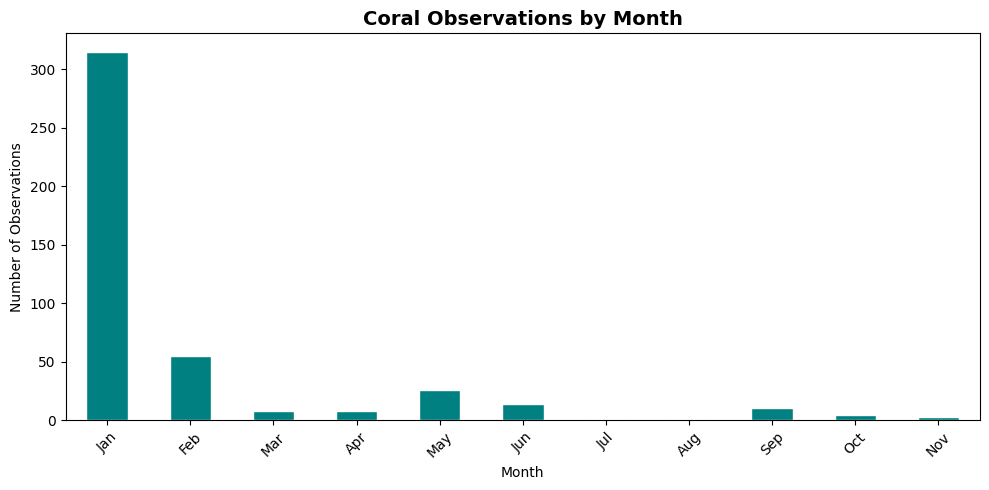

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly = df['month'].value_counts().sort_index()
monthly.index = monthly.index.map(month_names)

monthly.plot(
    kind='bar',
    ax=ax,
    color='teal',
    edgecolor='white'
)

ax.set_title('Coral Observations by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Observations')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [46]:
# Let's investigate the January spike
print("How many records have month data:")
print(df['month'].value_counts(dropna=False))

How many records have month data:
month
1     315
2      55
5      26
6      14
9      11
3       8
4       8
10      5
11      3
7       1
8       1
Name: count, dtype: int64


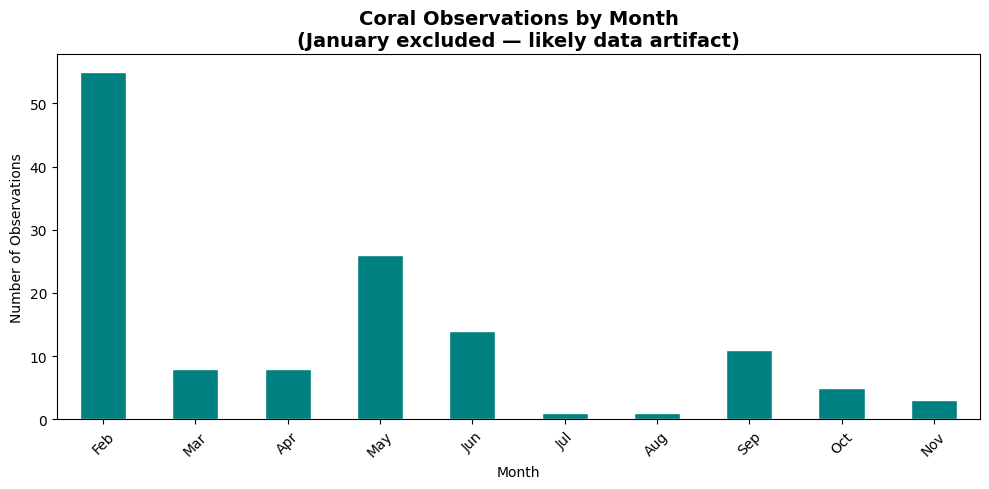

Records used for seasonality analysis: 132 out of 447


In [47]:
# FINDING: January spike is likely a data quality artifact
# Many GBIF records default to month=1 when exact date is unknown
# We'll exclude January from seasonality analysis to avoid misleading conclusions

df_season = df[df['month'] != 1].copy()

month_names = {2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

fig, ax = plt.subplots(figsize=(10, 5))

monthly = df_season['month'].value_counts().sort_index()
monthly.index = monthly.index.map(month_names)

monthly.plot(kind='bar', ax=ax, color='teal', edgecolor='white')

ax.set_title('Coral Observations by Month\n(January excluded — likely data artifact)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Observations')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Records used for seasonality analysis: {len(df_season)} out of {len(df)}")

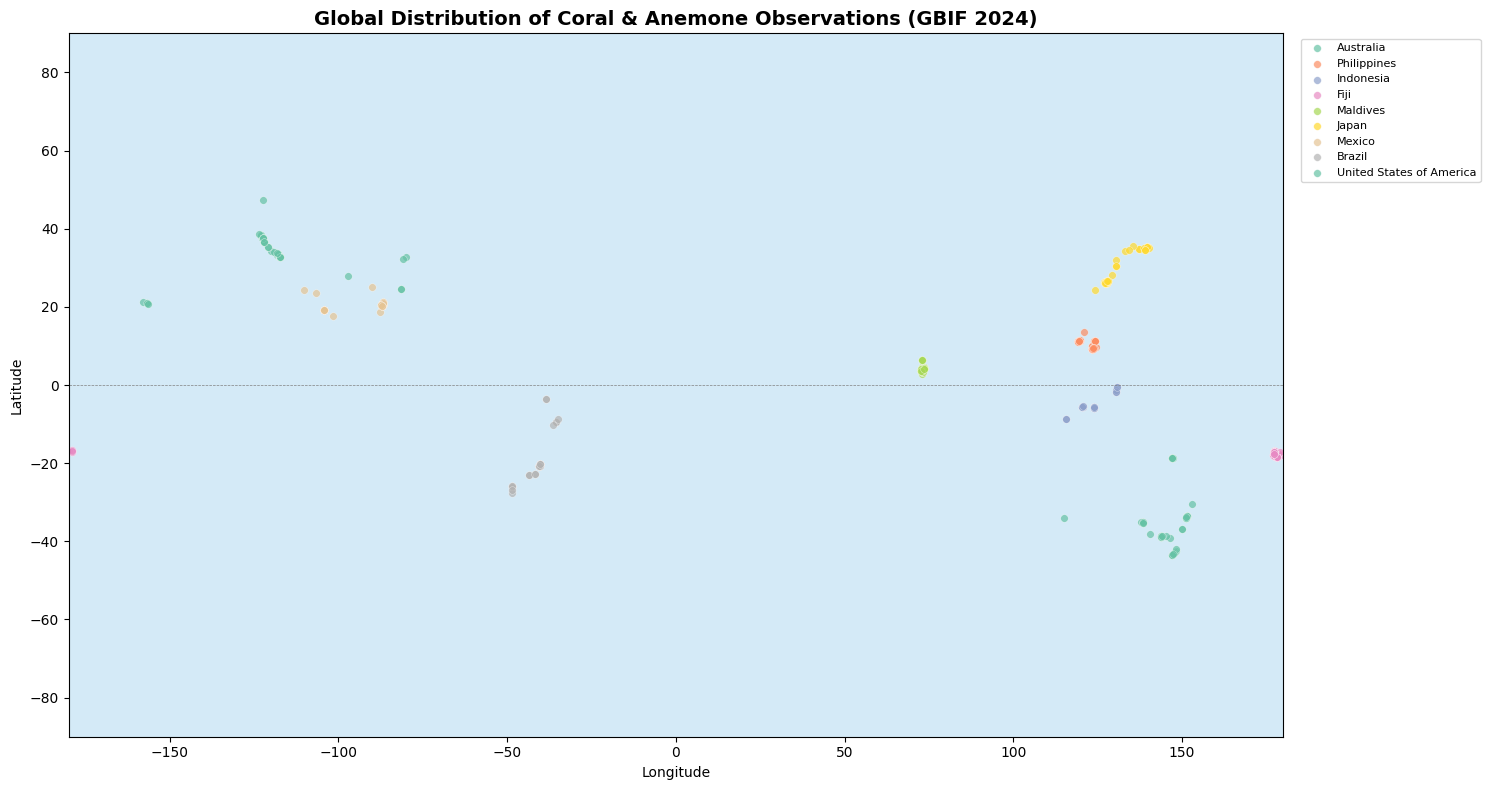

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(15, 8))

# Draw a simple world background
ax.set_facecolor('#d4eaf7')  # ocean color
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')  # equator

# Plot each country with a different color
countries = df['country'].unique()
colors = plt.cm.Set2.colors  # nice color palette

for i, country in enumerate(countries):
    subset = df[df['country'] == country]
    ax.scatter(
        subset['decimalLongitude'],
        subset['decimalLatitude'],
        label=country,
        color=colors[i % len(colors)],
        s=30,
        alpha=0.7,
        edgecolors='white',
        linewidths=0.3
    )

ax.set_title('Global Distribution of Coral & Anemone Observations (GBIF 2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

plt.tight_layout()
plt.show()

## Key Findings

**Dataset:** 447 observations of class Anthozoa (corals & anemones) 
from 9 countries, sourced from GBIF citizen science records (2024).

**1. Geographic distribution**
Observations are concentrated in tropical and subtropical zones, 
consistent with known coral reef biogeography. The Indo-Pacific 
region (Australia, Philippines, Indonesia, Fiji, Maldives) shows 
strong representation.

**2. Species composition**
The most observed species are sea anemones (*Anthopleura sola*, 
*Radianthus magnifica*, *Entacmaea quadricolor*), not hard corals. 
This likely reflects observer bias — anemones are visually striking 
and frequently photographed by divers.

**3. Seasonality**
After removing a data artifact (January default dates), February 
and May emerge as peak observation months, likely reflecting 
diving seasons in the Southern Hemisphere and pre-monsoon 
periods in tropical Asia.

**4. Data quality note**
70% of records (315/447) had month=1, suggesting missing date 
metadata defaulting to January. This highlights an important 
limitation of citizen science data that should be considered 
in any downstream analysis.

**Data source:** GBIF.org via pygbif API  
**Tools:** Python, pandas, matplotlib, plotly